In [96]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

In [97]:
df=pd.read_csv("sample_data.csv")

In [98]:
df.head()

,id,month,tot_voice_rev,total_data_rev,tot_rev,voip_tot_calls,total_calls_lwp,total_data_volume,total_calls_m_new,voip_usage_tag,customer_id,Consistency_Tag
0,1,5,143.5100,4.3388,147.8488,0,45.0,15.479279,158.0,low,1,MV_Consistent_New
1,2,5,12.7200,135.7747,149.4947,58,81.0,5768.832127,81.0,midium,2,MV_Degrowth_New
2,3,5,203.3676,0.0000,212.3876,0,268.0,NaN,269.0,low,3,MV_Degrowth_New
3,4,5,574.1087,0.0000,574.1087,0,448.0,0.000893,448.0,low,4,HV_Consistent_New
4,5,5,248.2312,283.0919,531.3231,83,371.0,11062.358541,579.0,midium,5,HV_Consistent_New


In [99]:
df.tail()

,id,month,tot_voice_rev,total_data_rev,tot_rev,voip_tot_calls,total_calls_lwp,total_data_volume,total_calls_m_new,voip_usage_tag,customer_id,Consistency_Tag
95,1543320,9,38.5250,131.9640,471.1756,441,1340.0,7799.427855,1340.0,High,16,HV_Consistent_New
96,1543321,9,182.3067,0.0000,200.3067,0,NaN,NaN,365.0,low,17,MV_Consistent_New
97,1543322,9,19.8500,178.2423,198.0923,4,36.0,3489.881124,46.0,Zero_voip_call,18,HV_Degrowth_New
98,1543323,9,146.3200,21.1662,170.2362,4,430.0,293.756021,430.0,Zero_voip_call,19,MV_Consistent_New
99,1543324,9,515.0066,35.9059,849.5991,14,1334.0,554.343118,1334.0,Zero_voip_call,20,HV_Consistent_New


In [100]:
df.shape

(100, 12)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   month              100 non-null    int64  
 2   tot_voice_rev      98 non-null     float64
 3   total_data_rev     98 non-null     float64
 4   tot_rev            98 non-null     float64
 5   voip_tot_calls     100 non-null    int64  
 6   total_calls_lwp    72 non-null     float64
 7   total_data_volume  67 non-null     float64
 8   total_calls_m_new  99 non-null     float64
 9   voip_usage_tag     100 non-null    object 
 10  customer_id        100 non-null    int64  
 11  Consistency_Tag    100 non-null    object 
dtypes: float64(6), int64(4), object(2)
memory usage: 9.5+ KB


- There are 100 Rows and 12 Columns in this data.
- There are 10 Numeric and 2 Categorical Columns.

In [103]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,100.0,771662.500000,548389.197288,1.000000,385831.7500,771662.500000,1.157493e+06,1.543324e+06
month,100.0,7.000000,1.421338,5.000000,6.0000,7.000000,8.000000e+00,9.000000e+00
tot_voice_rev,98.0,137.174503,151.261069,0.000000,16.3025,102.362300,1.843722e+02,6.056066e+02
total_data_rev,98.0,89.705711,153.472083,0.000000,0.0000,1.265500,1.209247e+02,6.248713e+02
tot_rev,98.0,298.924771,278.170320,0.025400,104.4757,189.421400,4.923887e+02,1.018650e+03
voip_tot_calls,100.0,65.060000,163.781871,0.000000,0.0000,0.000000,3.100000e+01,9.160000e+02
total_calls_lwp,72.0,358.944444,375.244142,0.000000,67.0000,220.500000,5.435000e+02,1.432000e+03
total_data_volume,67.0,5589.105497,7296.500287,0.000175,145.7466,2189.620872,8.163694e+03,2.880448e+04
total_calls_m_new,99.0,328.535354,360.951049,0.000000,60.0000,202.000000,4.420000e+02,1.432000e+03
customer_id,100.0,10.500000,5.795331,1.000000,5.7500,10.500000,1.525000e+01,2.000000e+01


In [104]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,100.0,NaN,NaN,NaN,771662.5,548389.197288,1.0,385831.75,771662.5,1157493.25,1543324.0
month,100.0,NaN,NaN,NaN,7.0,1.421338,5.0,6.0,7.0,8.0,9.0
tot_voice_rev,98.0,NaN,NaN,NaN,137.174503,151.261069,0.0,16.3025,102.3623,184.37215,605.6066
total_data_rev,98.0,NaN,NaN,NaN,89.705711,153.472083,0.0,0.0,1.2655,120.924725,624.8713
tot_rev,98.0,NaN,NaN,NaN,298.924771,278.17032,0.0254,104.4757,189.4214,492.388675,1018.65
voip_tot_calls,100.0,NaN,NaN,NaN,65.06,163.781871,0.0,0.0,0.0,31.0,916.0
total_calls_lwp,72.0,NaN,NaN,NaN,358.944444,375.244142,0.0,67.0,220.5,543.5,1432.0
total_data_volume,67.0,NaN,NaN,NaN,5589.105497,7296.500287,0.000175,145.7466,2189.620872,8163.694211,28804.478868
total_calls_m_new,99.0,NaN,NaN,NaN,328.535354,360.951049,0.0,60.0,202.0,442.0,1432.0
voip_usage_tag,100,4,low,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Null values

In [106]:
df=df.drop('customer_id',axis=1)

In [107]:
df.isnull().mean()*100

id                    0.0
month                 0.0
tot_voice_rev         2.0
total_data_rev        2.0
tot_rev               2.0
voip_tot_calls        0.0
total_calls_lwp      28.0
total_data_volume    33.0
total_calls_m_new     1.0
voip_usage_tag        0.0
Consistency_Tag       0.0
dtype: float64

## Replace by mean,median,mode

<Axes: xlabel='tot_voice_rev'>

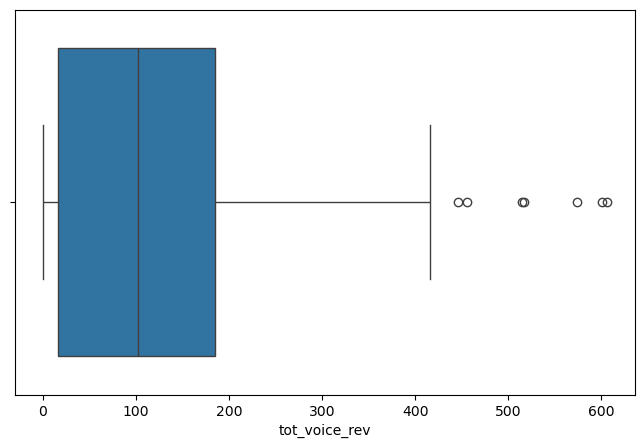

In [109]:
# tot_voice_rev
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='tot_voice_rev') # outliers are there we need to use median

In [110]:
df['tot_voice_rev']=df['tot_voice_rev'].fillna(df['tot_voice_rev'].median())

<Axes: xlabel='total_data_rev'>

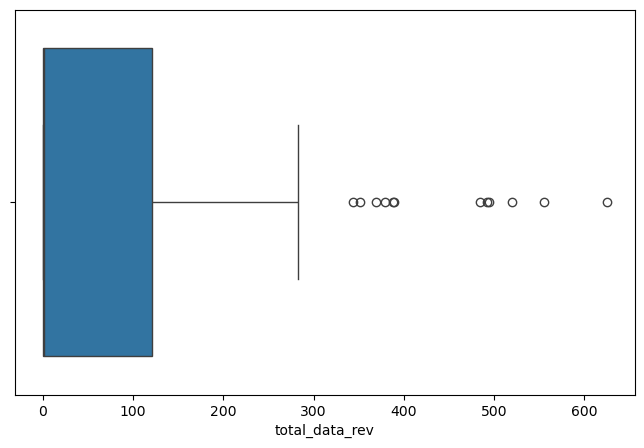

In [111]:
# total_data_rev
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='total_data_rev') # outliers are there we need to use median

In [112]:
df['total_data_rev']=df['total_data_rev'].fillna(df['total_data_rev'].median())

<Axes: xlabel='tot_rev'>

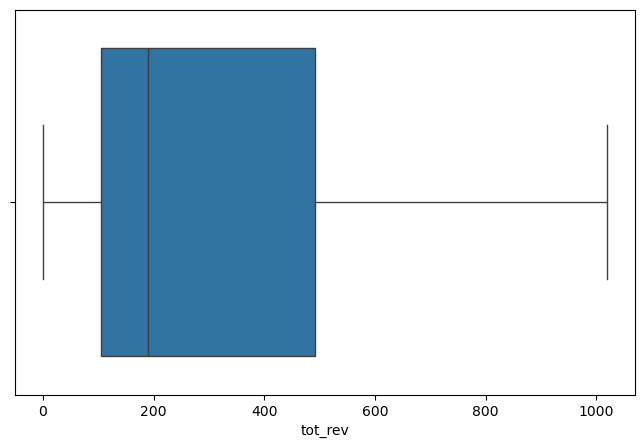

In [113]:
# tot_rev
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='tot_rev') # outliers are not there so we need to use mean

In [114]:
df['tot_rev']=df['tot_rev'].fillna(df['tot_rev'].mean())

<Axes: xlabel='total_calls_lwp'>

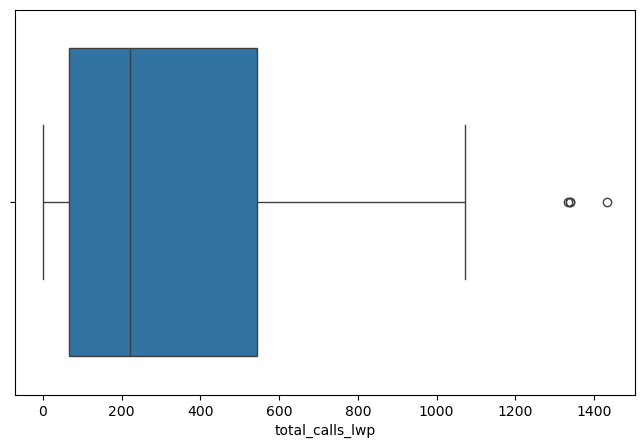

In [115]:
# total_calls_lwp
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='total_calls_lwp') # outliers are there so we need to use median

In [116]:
df['total_calls_lwp']=df['total_calls_lwp'].fillna(df['total_calls_lwp'].median())

<Axes: xlabel='total_data_volume'>

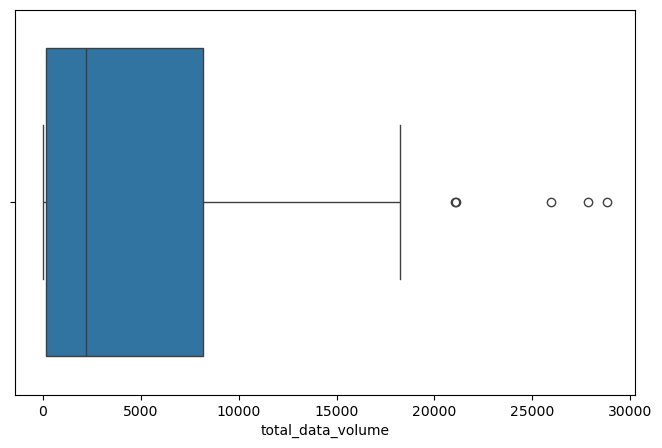

In [117]:
# total_data_volume
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='total_data_volume') # outliers are there so we need to use median

In [118]:
df['total_data_volume']=df['total_data_volume'].fillna(df['total_data_volume'].median())

<Axes: xlabel='total_calls_m_new'>

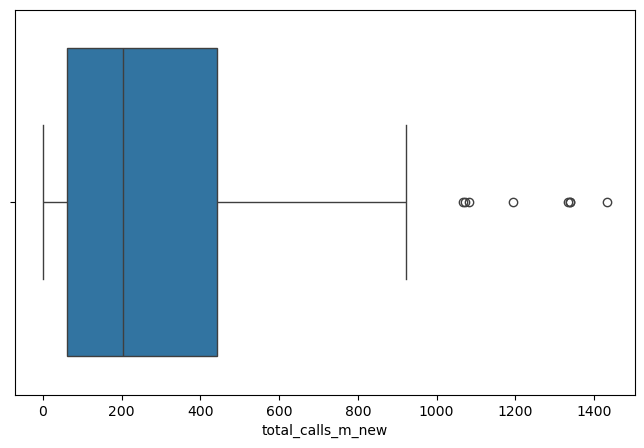

In [119]:
# total_calls_m_new
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='total_calls_m_new') # outliers are there so we need to use median

In [120]:
df['total_calls_m_new']=df['total_calls_m_new'].fillna(df['total_calls_m_new'].median())

In [121]:
df.isnull().mean()*100

id                   0.0
month                0.0
tot_voice_rev        0.0
total_data_rev       0.0
tot_rev              0.0
voip_tot_calls       0.0
total_calls_lwp      0.0
total_data_volume    0.0
total_calls_m_new    0.0
voip_usage_tag       0.0
Consistency_Tag      0.0
dtype: float64

- Null values are filled.

In [123]:
df.head()

,id,month,tot_voice_rev,total_data_rev,tot_rev,voip_tot_calls,total_calls_lwp,total_data_volume,total_calls_m_new,voip_usage_tag,Consistency_Tag
0,1,5,143.5100,4.3388,147.8488,0,45.0,15.479279,158.0,low,MV_Consistent_New
1,2,5,12.7200,135.7747,149.4947,58,81.0,5768.832127,81.0,midium,MV_Degrowth_New
2,3,5,203.3676,0.0000,212.3876,0,268.0,2189.620872,269.0,low,MV_Degrowth_New
3,4,5,574.1087,0.0000,574.1087,0,448.0,0.000893,448.0,low,HV_Consistent_New
4,5,5,248.2312,283.0919,531.3231,83,371.0,11062.358541,579.0,midium,HV_Consistent_New


## Check for duplicated rows in the data

In [125]:
df[df.duplicated()]

,id,month,tot_voice_rev,total_data_rev,tot_rev,voip_tot_calls,total_calls_lwp,total_data_volume,total_calls_m_new,voip_usage_tag,Consistency_Tag


- no duplicate rows

## Highly imbalanced data

- A feature is highly imbalanced when the majority class makes up 90% or more of the data.
- If one category is >95%, it's highly imbalanced, and you can drop it

In [129]:
# voip_usage_tag
print(df["voip_usage_tag"].value_counts(normalize=True) * 100)

voip_usage_tag
low               55.0
Zero_voip_call    22.0
High              14.0
midium             9.0
Name: proportion, dtype: float64


In [130]:
# Consistency_Tag
print(df["Consistency_Tag"].value_counts(normalize=True) * 100)

Consistency_Tag
MV_Degrowth_New      41.0
HV_Consistent_New    30.0
MV_Consistent_New    24.0
HV_Degrowth_New       5.0
Name: proportion, dtype: float64


- dataset is evenly distributed.

## Seperate num and cat variables

In [133]:
num_col=df.select_dtypes(include=np.number).columns.to_list()
print(num_col)

['id', 'month', 'tot_voice_rev', 'total_data_rev', 'tot_rev', 'voip_tot_calls', 'total_calls_lwp', 'total_data_volume', 'total_calls_m_new']


In [134]:
num_col1=df.select_dtypes(include=np.number)
print(num_col1)

         id  month  tot_voice_rev  total_data_rev   tot_rev  voip_tot_calls  \
0         1      5       143.5100          4.3388  147.8488               0   
1         2      5        12.7200        135.7747  149.4947              58   
2         3      5       203.3676          0.0000  212.3876               0   
3         4      5       574.1087          0.0000  574.1087               0   
4         5      5       248.2312        283.0919  531.3231              83   
..      ...    ...            ...             ...       ...             ...   
95  1543320      9        38.5250        131.9640  471.1756             441   
96  1543321      9       182.3067          0.0000  200.3067               0   
97  1543322      9        19.8500        178.2423  198.0923               4   
98  1543323      9       146.3200         21.1662  170.2362               4   
99  1543324      9       515.0066         35.9059  849.5991              14   

    total_calls_lwp  total_data_volume  total_calls

In [135]:
cat_col=df.select_dtypes(include=object).columns.to_list()
print(cat_col)

['voip_usage_tag', 'Consistency_Tag']


In [136]:
cat_col1=df.select_dtypes(include=object)
print(cat_col1)

    voip_usage_tag    Consistency_Tag
0              low  MV_Consistent_New
1           midium    MV_Degrowth_New
2              low    MV_Degrowth_New
3              low  HV_Consistent_New
4           midium  HV_Consistent_New
..             ...                ...
95            High  HV_Consistent_New
96             low  MV_Consistent_New
97  Zero_voip_call    HV_Degrowth_New
98  Zero_voip_call  MV_Consistent_New
99  Zero_voip_call  HV_Consistent_New

[100 rows x 2 columns]


## Univariate analysis on numeric variable:

In [138]:
# 1. Target - Consistency_Tag

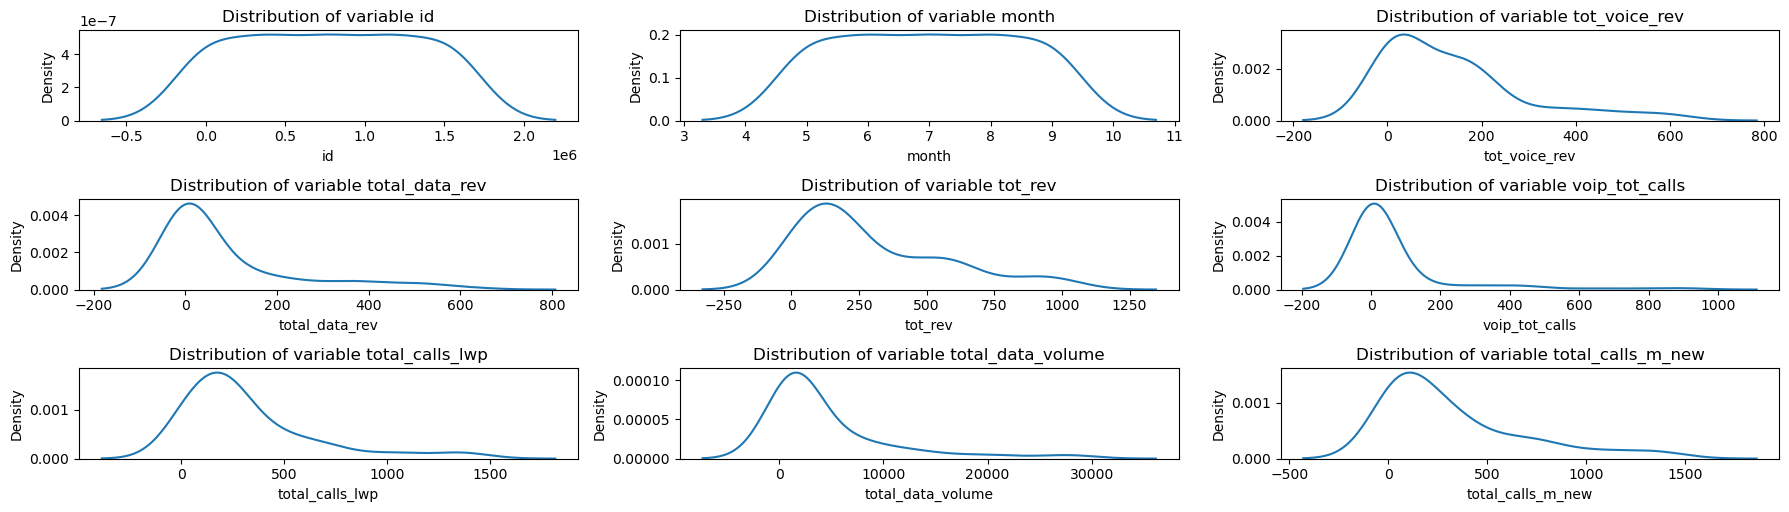

In [139]:
plt.rcParams['figure.figsize'] = [18,20]
t=1
for i in num_col:
    if i != 'SalePrice':
        plt.subplot(12,3,t)
        sns.kdeplot(df[i])
        plt.title(f'Distribution of variable {i}')
        t+=1
plt.tight_layout()
plt.show()

In [140]:
df[num_col].skew()

id                   0.000000
month                0.000000
tot_voice_rev        1.450305
total_data_rev       1.896457
tot_rev              1.055643
voip_tot_calls       3.408555
total_calls_lwp      1.757649
total_data_volume    2.277338
total_calls_m_new    1.430006
dtype: float64

## Univariate analysis on catogarical variable:

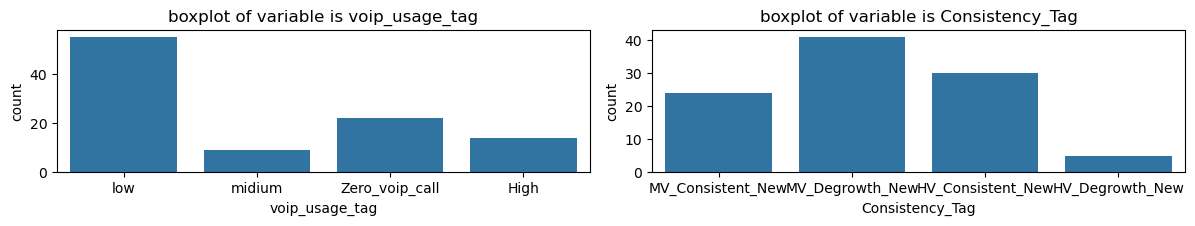

In [142]:
plt.rcParams['figure.figsize'] = [18,20]
t=1
for i in cat_col:
    plt.subplot(10,3,t)
    sns.countplot(x=df[i])
    plt.title(f"boxplot of variable is {i}")
    t+=1
plt.tight_layout()
plt.show()

In [143]:
for i in cat_col:
    print(df[i].value_counts(normalize=True)*100)
    print("------------------------------------------------------------------------")

voip_usage_tag
low               55.0
Zero_voip_call    22.0
High              14.0
midium             9.0
Name: proportion, dtype: float64
------------------------------------------------------------------------
Consistency_Tag
MV_Degrowth_New      41.0
HV_Consistent_New    30.0
MV_Consistent_New    24.0
HV_Degrowth_New       5.0
Name: proportion, dtype: float64
------------------------------------------------------------------------


## Bivariate analysis 

- num vs cat (Target vs Cat) Mean estimation

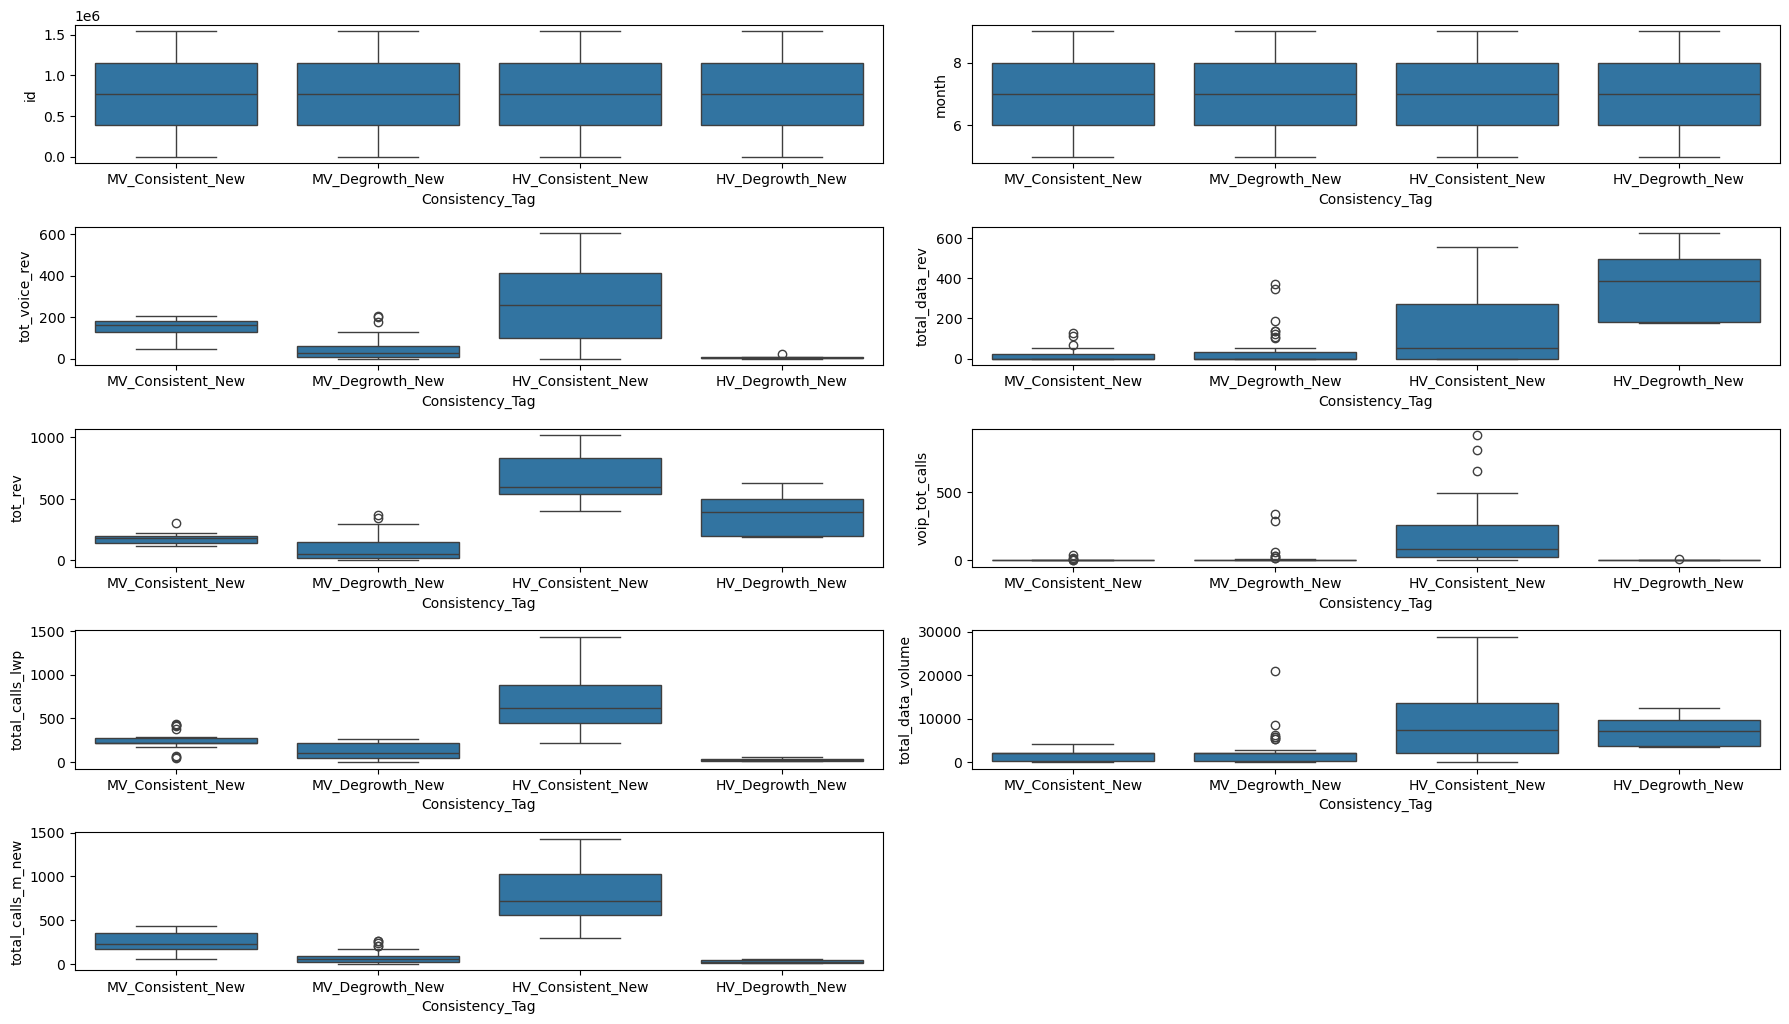

In [146]:
plt.rcParams['figure.figsize'] = [18,20]
t=1
for i in num_col:
    plt.subplot(10,2,t)
    sns.boxplot(y=df[i],x=df['Consistency_Tag'])
    t+=1
plt.tight_layout()
plt.show()

- cat vs cat

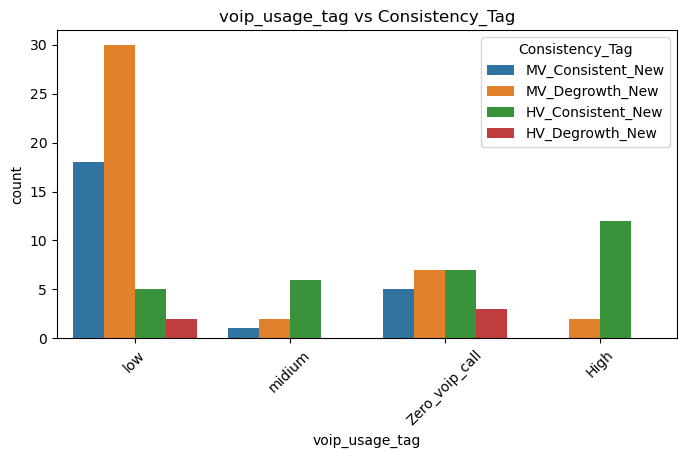

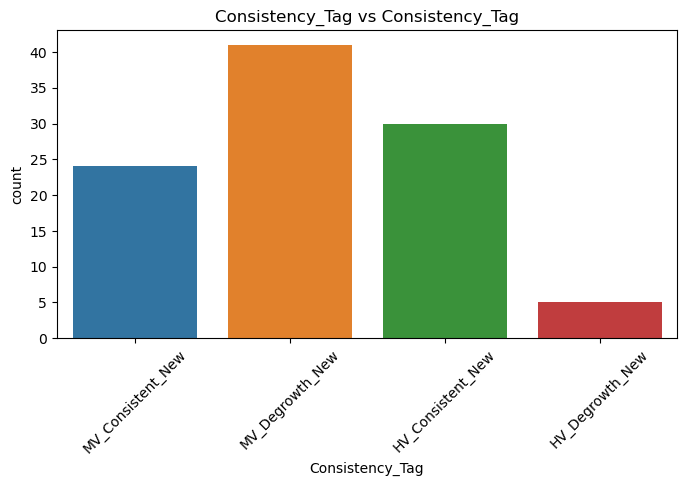

In [148]:
for col in cat_col:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='Consistency_Tag', data=df)
    plt.title(f'{col} vs Consistency_Tag')
    plt.xticks(rotation=45)
    plt.show()

## Multivariate analysis

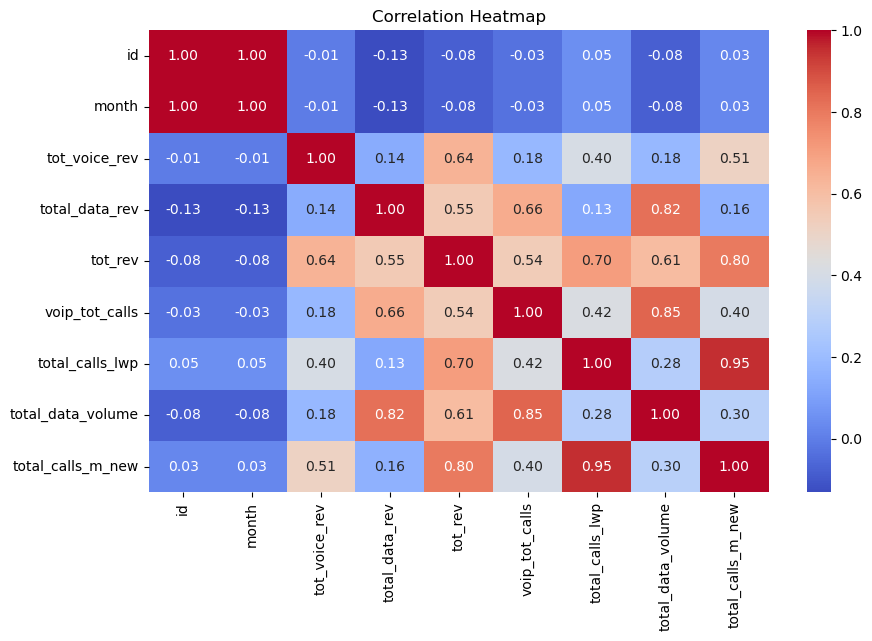

In [150]:
corr_matrix = num_col1.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ---- Covariance ----
cov_matrix = num_col1.cov()

## Encoding

- voip_usage_tag (ordinal encoding)

In [153]:
df['voip_usage_tag'].unique()

array(['low', 'midium', 'Zero_voip_call', 'High'], dtype=object)

In [154]:
# voip_usage_tag
order = [['Zero_voip_call', 'low', 'midium', 'High']] 
encoder = OrdinalEncoder(categories=order)
df['voip_usage_encoded'] = encoder.fit_transform(df[['voip_usage_tag']])

- Consistency_Tag

In [156]:
df['Consistency_Tag'].unique()

array(['MV_Consistent_New', 'MV_Degrowth_New', 'HV_Consistent_New',
       'HV_Degrowth_New'], dtype=object)

In [157]:
# Binary Encoding: Consistent = 1, Degrowth = 0
df['Consistency_Binary'] = np.where(df['Consistency_Tag'].str.contains('Consistent'), 1, 0)

## drop columns - voip_usage_tag, Consistency_Tag

In [159]:
df=df.drop(['voip_usage_tag','Consistency_Tag'],axis=1)

## Transformation (to reduce the skewness)

In [161]:
df[num_col].skew()

id                   0.000000
month                0.000000
tot_voice_rev        1.450305
total_data_rev       1.896457
tot_rev              1.055643
voip_tot_calls       3.408555
total_calls_lwp      1.757649
total_data_volume    2.277338
total_calls_m_new    1.430006
dtype: float64

In [162]:
skewed_cols = [
    'tot_voice_rev',
    'total_data_rev',
    'tot_rev',
    'voip_tot_calls',
    'total_calls_lwp',
    'total_data_volume',
    'total_calls_m_new'
]

In [163]:
pt = PowerTransformer(method='yeo-johnson')
df[skewed_cols] = pt.fit_transform(df[skewed_cols])

In [164]:
df[skewed_cols].skew()

tot_voice_rev       -0.166870
total_data_rev       0.287024
tot_rev             -0.112568
voip_tot_calls       0.417048
total_calls_lwp     -0.034628
total_data_volume   -0.186226
total_calls_m_new   -0.095555
dtype: float64

## Train test split

In [166]:
X = df.drop('Consistency_Binary', axis=1)   # all features
y = df['Consistency_Binary']                # target variable

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,          # 30% test data
    random_state=42,        # ensures reproducibility
    stratify=y              # keeps target class distribution same in both sets
)

## Model building

- 1. Logistic Regression

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [171]:
# Predict
y_pred = logreg.predict(X_test)

In [172]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Assuming y_test and y_pred are already defined
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Full Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9333333333333333
Precision: 0.9375
Recall: 0.9375
F1 Score: 0.9375
Confusion Matrix:
 [[13  1]
 [ 1 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.94      0.94      0.94        16

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



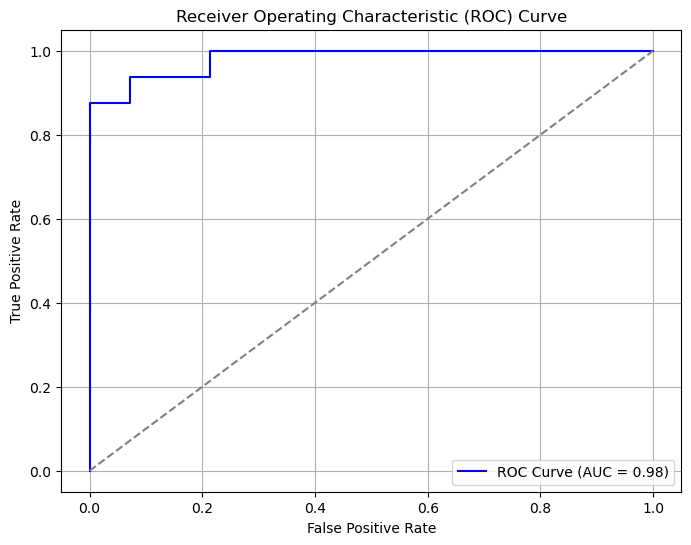

In [173]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities (not just class labels)
y_probs = logreg.predict_proba(X_test)[:, 1]  # Probability estimates for class 1

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


- 2. Random Forest Classifier

In [175]:
from sklearn.ensemble import RandomForestClassifier    # ChatGPT

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [176]:
# Predict
y_pred = rf.predict(X_test)

In [177]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Assuming y_test and y_pred are already defined
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Full Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9
Precision: 0.8823529411764706
Recall: 0.9375
F1 Score: 0.9090909090909091
Confusion Matrix:
 [[12  2]
 [ 1 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.88      0.94      0.91        16

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



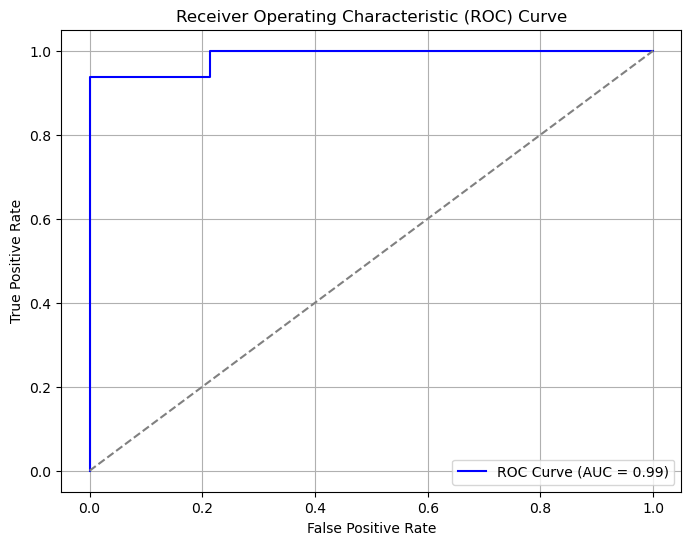

In [178]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities (not just class labels)
y_probs = rf.predict_proba(X_test)[:, 1]  # Probability estimates for class 1

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


- 3. Gradient Boosting Classifier

In [180]:
from sklearn.ensemble import GradientBoostingClassifier  #ChatGPT
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [181]:
# Predict
y_pred = gbc.predict(X_test)

In [182]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Assuming y_test and y_pred are already defined
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Full Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8666666666666667
Precision: 0.8333333333333334
Recall: 0.9375
F1 Score: 0.8823529411764706
Confusion Matrix:
 [[11  3]
 [ 1 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.79      0.85        14
           1       0.83      0.94      0.88        16

    accuracy                           0.87        30
   macro avg       0.88      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30



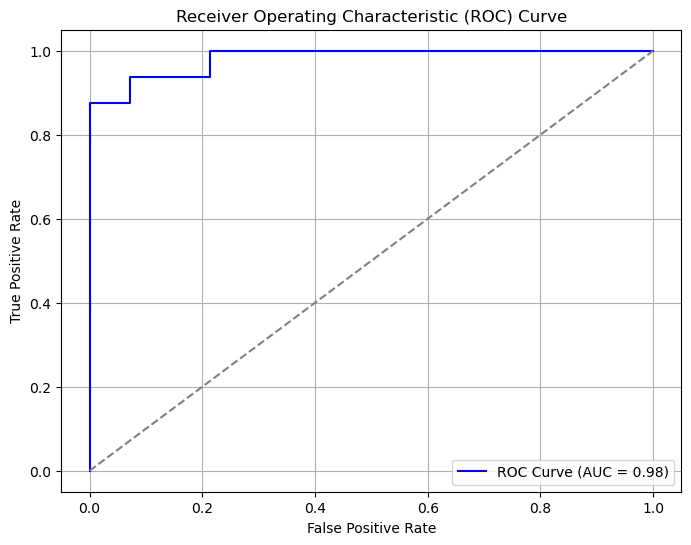

In [183]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities (not just class labels)
y_probs = gbc.predict_proba(X_test)[:, 1]  # Probability estimates for class 1

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
